Equipo
Integrantes:
- Carla Sophia Rodríguez Dander - A01781793
- Isaac Husny - A01027140
- Jesus Rodríguez - A01025112


##Librerias

In [ ]:
! pip install plotly
! pip install plotly_express
! pip install raceplotly
! pip install kaleido

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lida 0.0.10 requires fastapi, which is not installed.
lida 0.0.10 requires python-multipart, which is not installed.
lida 0.0.10 requires uvicorn, which is not installed.


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from raceplotly.plots import barplot

##Carga de CSV

In [ ]:
drive.mount('/content/drive')
path='/content/drive/Shareddrives/COLAB DATOS DE LIVERPOOL/Datos Liverpool/'
Historico=pd.read_csv(path+'HistoricoLimpio.csv')
Demo=pd.read_csv(path+'DemoLimpio.csv')

Mounted at /content/drive


In [ ]:
pd.options.display.max_columns = None
display(Historico.head(n=2))
display(Demo.head(n=2))

,Nº pers.,Fecha Salida,HAño,HMes,Desde,DAño,DMes,Duracion,Desc Soc,Locación,GroPer,Área Personal,Departamento,Unidad,Desc Función,Duración Días
0,3369,1999-12-31,1999,12,1999-01-01,1999,1,0.997260,Servicios Liverpool S.A.,Servicios Liverpool,Planta No Sind.,Ejecutivo/ Coord.,JUNIORS,Compras Juniors,Comprador Sr B,364
1,3369,2004-01-31,2004,1,2000-01-01,2000,1,4.084932,Servicios Liverpool S.A.,Servicios Liverpool,Planta No Sind.,Ejecutivo/ Coord.,JUNIORS,Compras Juniors,Comprador Sr B,1491


,Nº pers.,Fecha nacimiento,NAño,NMes,NDia,Genero,No Hijos,Fecha ingreso,IAño,IMes,Edad ingreso,Fecha Salida,SAño,SMes,Antigüedad,Edad salida,Año salida,Desc Medida,Ultima Evaluación,CP Vivienda,CP Trabajo,Locación,Desc Fun,GroPer,Área Personal,Departamento,Unidad,Desc Soc,Duración Días,Antigüedad_Grupos
0,13307867,1997-03-13,1997,3,13,Mujer,0,2015-06-26,2015,6,18,2022-12-14,2022,12,7,25,2022,Baja Suburbia,3.16,23562,234,Suburbia Los Cabos Patio,Cajero,SBB Planta,SBB Operación,CAJAS,Jefatura Cajas SBB Patio,Suburbia S. de R.L. de CV,2728,2
1,14877876,1991-05-14,1991,5,14,Hombre,0,2019-02-01,2019,2,27,2021-10-16,2021,10,2,30,2021,Baja,3.00,23400,234,Boutique Los Cabos,Vendedor Bilingue,Planta No Sind.,TC. Vendedor,FRAGANCIAS,Ventas Boutique Los Cabos,"Distribuidora Liverpool,",988,1


##Info General (Para la Narrativa de Datos en la Presentación)

###Género y Desc Medida

In [ ]:
# Gráfico de pastel interactivo para la variable 'Genero'
fig_genero = px.pie(Demo, names='Genero', title='Distribución por Género')

# Gráfico de pastel interactivo para la variable 'Desc Medida'
fig_desc_medida = px.pie(Demo, names='Desc Medida', title='Distribución por Desc Medida')

# Mostrar los gráficos interactivos
fig_genero.show()
fig_desc_medida.show()

###Distribución grupo persona y No. Hijos

In [ ]:
# Calcular la frecuencia de género
frecuencia_gro = Demo.groupby(['GroPer']).size().reset_index(name='Frecuencia')
#Se crea el grafico circular en plotly express
fig = px.pie(frecuencia_gro,
          width=700,
          height=500,
          values='Frecuencia',
          names='GroPer',
          hole=0.35,
          color_discrete_sequence=px.colors.sequential.Plasma,
          labels={
          "GroPer": "Pais"},
          title="Distribución Grupo Persona")

fig.update_traces(pull=[0, 0, 0.1, 0, 0, 0, 0, 0])
fig.show()

In [ ]:
datos_agrupados = Demo.groupby(['Genero', 'No Hijos']).size().reset_index(name='Número de Personas')

# Crea el gráfico de barras apiladas
fig = px.bar(datos_agrupados,
             width=900,
             height=600,
             x='Genero', y='Número de Personas', color='No Hijos',
             title='Número de Hijos por Género',
             labels={'Número de Personas': 'Frecuencia de Renuncias', 'No Hijos': 'Hijos', 'Genero': ' Género'},
             barmode='stack')  # Utiliza 'stack' para apilar las barras

# Muestra el gráfico
fig.show()

In [ ]:
con_hijos = Demo[Demo['No Hijos'] > 0]

# Cuenta el número de hijos por género para los que tienen hijos
conteo_hijos_por_genero = con_hijos.groupby('Genero')['No Hijos'].sum().reset_index()

# Crea el gráfico de barras
fig = px.bar(conteo_hijos_por_genero, x='Genero', y='No Hijos',
             title='Número de Hijos por Género (Excluyendo Personas sin Hijos)',
             labels={'No Hijos': 'Número de Hijos', 'Genero': 'Género'},
             color='Genero', color_discrete_sequence=px.colors.qualitative.Set3)

# Muestra el gráfico
fig.show()

In [ ]:
on_hijos = Demo[Demo['No Hijos'] > 0]

# Filtra las filas donde 'No Hijos' es 0 (es decir, no tienen hijos)
sin_hijos = Demo[Demo['No Hijos'] == 0]

# Conteo de número de hijos por género para los que tienen hijos
conteo_hijos_por_genero = con_hijos.groupby('Genero')['No Hijos'].sum().reset_index()

# Conteo de número de personas sin hijos por género
conteo_sin_hijos_por_genero = sin_hijos['Genero'].value_counts().reset_index().rename(columns={'index': 'Genero', 'Genero': 'Count'})

# Combinar los dos conjuntos de datos para el conteo final
conteo_total_por_genero = pd.merge(conteo_hijos_por_genero, conteo_sin_hijos_por_genero, on='Genero', how='outer')
conteo_total_por_genero.columns = ['Genero', 'Con Hijos', 'Sin Hijos']

# Crea un gráfico de barras apiladas
fig = px.bar(conteo_total_por_genero, x='Genero', y=['Con Hijos', 'Sin Hijos'],
             title='Conteo de Número de Hijos por Género (Con y Sin Hijos)',
             labels={'value': 'Número de Personas', 'variable': 'Condición', 'Genero': 'Género'},
             color_discrete_sequence=['#1f77b4', '#ff7f0e'])

# Muestra el gráfico
fig.show()

###Año Salida

####General

In [ ]:
frecuencia_anio_salida = Demo.groupby('Año salida').size().reset_index(name='Frecuencia')

# Crear el gráfico de líneas
fig = px.line(frecuencia_anio_salida,
              x="Año salida",
              y="Frecuencia",
              labels={"Año salida": "Año de salida de los empleados", "Frecuencia": "Número de bajas"},
              title='Año de Salida vs Frecuencia de Bajas (General)')

fig.update_layout(
    width=1000,  # Ancho
    height=500  # Altura
)

fig.update_xaxes(dtick=1)  # Evitar valores intermedios en el eje x
fig.show()

#### Por Genero

In [ ]:
# Calcular la frecuencia del género para cada año de salida GENERAL
frecuencia_genero = Demo.groupby(['Año salida', 'Genero']).size().reset_index(name='Frecuencia')

fig = px.line(frecuencia_genero,
           x="Año salida",
           y="Frecuencia",
           color="Genero",
           labels={"Año salida": "Año de salida de los empleados", "Frecuencia": "Número de bajas", "Genero": "Género"},
           title='Año de Salida vs Frecuencia de Bajas')

fig.update_layout(
    width=1000,  # Ancho
    height=500  # Altura
)

fig.update_xaxes(dtick=1)  # Evitamos valores intermedios
fig.show()

###Mes Salida

In [ ]:
# Calcular la frecuencia del género para cada año de salida
frecuencia_genero = Demo.groupby(['SMes', 'Genero']).size().reset_index(name='Frecuencia')

# Diccionario para mapear números de mes a nombres de mes
meses_dict = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre',
}

# Mapea los números de mes a nombres de mes
frecuencia_genero['SMes'] = frecuencia_genero['SMes'].map(meses_dict)

#Se crea el gráfico de linea en plotly express
fig = px.line(frecuencia_genero,
           x="SMes",
           y="Frecuencia",
           color="Genero",
           labels={"SMes": "Mes", "Frecuencia": "Número de bajas", "Genero": "Género"},
           title='Mes de Salida (2019- 2023) vs Frecuencia de Bajas')

#Cambiamos el tamaño del gráfico
fig.update_layout(
    width=1200,  # Ancho
    height=600  # Altura
)

fig.update_xaxes(dtick=1)  # Evitamos valores intermedios

fig.show()

In [ ]:
# Eliminar la columna 'Genero' del DataFrame antes de calcular la frecuencia
frecuencia = Demo.groupby('SMes').size().reset_index(name='Frecuencia')

# Diccionario para mapear números de mes a nombres de mes
meses_dict = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre',
}

# Mapea los números de mes a nombres de mes
frecuencia['SMes'] = frecuencia['SMes'].map(meses_dict)

# Se crea el gráfico de línea en plotly express
fig = px.line(frecuencia,
              x="SMes",
              y="Frecuencia",
              labels={"SMes": "Mes", "Frecuencia": "Número de bajas"},
              title='Mes de Salida (2019-2023) vs Frecuencia de Bajas')

# Cambiamos el tamaño del gráfico
fig.update_layout(
    width=1200,  # Ancho
    height=600  # Altura
)

fig.update_xaxes(dtick=1)  # Evitamos valores intermedios

fig.show()


In [ ]:
frecuencia['Porcentaje'] = (frecuencia['Frecuencia'] / frecuencia['Frecuencia'].sum()) * 100

# Crear un gráfico de líneas con dos ejes y escalas diferentes
fig = go.Figure()

# Agregar la línea de número de bajas
fig.add_trace(go.Scatter(x=frecuencia['SMes'], y=frecuencia['Frecuencia'],
                         mode='lines+markers', name='Número de bajas'))

# Agregar la línea de porcentajes con un segundo eje y escala diferente
fig.add_trace(go.Scatter(x=frecuencia['SMes'], y=frecuencia['Porcentaje'],
                         mode='lines+markers', name='Porcentaje (%)'))

# Configurar el diseño del gráfico
fig.update_layout(
    title='Mes de Salida (2019-2023) vs Frecuencia de Bajas',
    xaxis=dict(tickmode='array', tickvals=frecuencia['SMes'], ticktext=frecuencia['SMes']),
    yaxis=dict(title='Número de bajas'),
    yaxis2=dict(title='Porcentaje (%)', overlaying='y', side='right', range=[0, 100]),
    width=1200,  # Ancho
    height=600,  # Altura
)

fig.show()

###Edad Salida

In [ ]:
# Calcular la frecuencia del género para cada año de salida GENERAL
frecuencia_genero = Demo.groupby(['Edad salida']).size().reset_index(name='Frecuencia')

fig = px.line(frecuencia_genero,
           x="Edad salida",
           y="Frecuencia",
           labels={"Edad salida": "Edad de salida de los empleados", "Frecuencia": "Número de bajas"},
           title='Edad de Salida vs Frecuencia de Bajas')

fig.update_layout(
    width=1500,  # Ancho
    height=600  # Altura
)

fig.update_xaxes(dtick=1)  # Evitamos valores intermedios
fig.show()

In [ ]:
# Calcular la frecuencia del género para cada año de salida GENERAL
frecuencia_genero = Demo.groupby(['Edad salida', 'Genero']).size().reset_index(name='Frecuencia')

fig = px.line(frecuencia_genero,
           x="Edad salida",
           y="Frecuencia",
           color="Genero",
           labels={"Edad salida": "Edad de salida de los empleados", "Frecuencia": "Número de bajas", "Genero": "Género"},
           title='Edad de Salida vs Frecuencia de Bajas')

fig.update_layout(
    width=1500,  # Ancho
    height=600  # Altura
)

fig.update_xaxes(dtick=1)  # Evitamos valores intermedios
fig.show()

###Funciones

In [ ]:
# Contar el número de ocurrencias para cada combinación única de "vendedor cajero" y "departamento"
conteo_funcion = Demo.groupby(['Desc Fun']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(n=25)
fig = px.bar(conteo_funcion,
          width=1000,
          height=600,
          x='Desc Fun',
          y='Count',
          color='Count',
          color_continuous_scale='YlGnBu',
          labels={
          "Count": "Cantidad de Renuncias", "Desc Fun": "Función"},
          title="Funciones con Mayores Renuncias")
fig.show()

In [ ]:
conteo_funcion_menor_bajas = Demo.groupby(['Desc Fun']).size().reset_index(name='Count').sort_values(by='Count', ascending=True).head(n=25)

# Crear el gráfico de barras para las funciones con menos bajas
fig_menor_bajas = px.bar(conteo_funcion_menor_bajas,
                         width=1000,
                         height=600,
                         x='Desc Fun',
                         y='Count',
                         color='Count',
                         color_continuous_scale='YlGnBu',
                         labels={"Count": "Cantidad de Renuncias", "Desc Fun": "Función"},
                         title="Funciones con Menores Renuncias")

fig_menor_bajas.show()

###Antigúedad y función

In [ ]:
antiguedad_promedio_por_puesto = Demo.groupby('Desc Fun')['Antigüedad'].mean().reset_index()

# Ordena los puestos por antigüedad promedio de menor a mayor
antiguedad_promedio_por_puesto = antiguedad_promedio_por_puesto.sort_values(by='Antigüedad', ascending=False).head(50)

# Crea el gráfico de barras con colores
fig = px.bar(antiguedad_promedio_por_puesto,
             width=1000,
             height=600,
             x='Desc Fun', y='Antigüedad',
             title='Antigüedad Promedio por Puesto',
             labels={'Antigüedad': 'Antigüedad Promedio', 'Desc Fun': 'Puesto'},
             color='Antigüedad',  # Colorear barras según el valor de antigüedad
             color_continuous_scale='Plasma'  # Escala de colores (puedes cambiarla según tu preferencia)
            )

# Muestra el gráfico
fig.show()

In [ ]:
antiguedad_promedio_por_puesto = antiguedad_promedio_por_puesto.sort_values(by='Antigüedad', ascending=True)

# Obtiene las funciones con los promedios más bajos de antigüedad (bottom 50)
funciones_con_menores_promedios = antiguedad_promedio_por_puesto.tail(60)

# Crea el gráfico de barras con colores
fig = px.bar(funciones_con_menores_promedios,
             width=1000,
             height=600,
             x='Desc Fun', y='Antigüedad',
             title='Antigüedad Promedio por Puesto (Promedios más Altos)',
             labels={'Antigüedad': 'Antigüedad Promedio', 'Desc Fun': 'Puesto'},
             color='Antigüedad',  # Colorear barras según el valor de antigüedad
             color_continuous_scale='Plasma'  # Escala de colores (puedes cambiarla según tu preferencia)
            )

# Muestra el gráfico
fig.show()

In [ ]:
promedio_antiguedad_por_funcion = Demo.groupby('Desc Fun')['Antigüedad'].mean().reset_index()

# Crear el gráfico de barras del promedio de antigüedad por función
fig = px.bar(promedio_antiguedad_por_funcion, x='Desc Fun', y='Antigüedad',
             labels={'Antigüedad': 'Promedio de Antigüedad', 'Desc Fun': 'Función'},
             title='Promedio de Antigüedad por Función',
             category_orders={"Desc Fun": promedio_antiguedad_por_funcion.sort_values('Antigüedad', ascending=False)['Desc Fun']})

# Configurar el diseño del gráfico
fig.update_layout(width=1000, height=600)

fig.show()

In [ ]:
promedio_antiguedad_por_funcion = Demo.groupby('Desc Fun')['Antigüedad'].mean().reset_index()

# Crear el gráfico de barras del promedio de antigüedad por función
fig = px.bar(promedio_antiguedad_por_funcion, x='Desc Fun', y='Antigüedad',
             labels={'Antigüedad': 'Promedio de Antigüedad', 'Desc Fun': 'Función'},
             title='Promedio de Antigüedad por Función')

# Resaltar la función "Vendedor Cajero" cambiando su color
fig.update_traces(marker_color='rgba(255, 0, 0, 1)', selector=dict(name='Vendedor Cajero'))

# Configurar el diseño del gráfico
fig.update_layout(width=1000, height=600)

fig.show()

###Locaciones

In [ ]:
num_locaciones = Demo['Locación'].nunique()
# Imprime el número de locaciones únicas
print(f'Número de Locaciones Únicas: {num_locaciones}')

Número de Locaciones Únicas: 565


In [ ]:
top_locaciones = Demo['Locación'].value_counts().nlargest(25).reset_index()
top_locaciones.columns = ['Locación', 'Count']

# Gráfico de barras horizontal con esquema de colores 'magma'
fig = px.bar(top_locaciones,
             y='Locación', x='Count', orientation='h',
             color='Count', title='Top 25 Locaciones Más Frecuentes',
             color_continuous_scale='Rainbow',
             labels={'Locación': 'Locación', 'Count': 'Número de Empleados'})

fig.show()


In [ ]:
# Obtén las 20 locaciones menos frecuentes para hacer el gráfico más legible
bottom_locaciones = Demo['Locación'].value_counts().nsmallest(25).reset_index()
bottom_locaciones.columns = ['Locación', 'Count']

# Gráfico de barras horizontal con esquema de colores 'magma'
fig = px.bar(bottom_locaciones, y='Locación', x='Count', orientation='h',
             color='Count', title='Bottom 25 Locaciones Menos Frecuentes',
             color_continuous_scale='magma',
             labels={'Locación': 'Locación', 'Count': 'Número de Empleados'})

fig.show()

In [ ]:
# Calcula la frecuencia de cada locación y ordena de mayor a menor
locacion_counts = Demo['Locación'].value_counts().reset_index().rename(columns={'index': 'Locación', 'Locación': 'Count'}).head(n=20)
locacion_counts = locacion_counts.sort_values(by='Count', ascending=False)

# Crea la gráfica de barras interactiva
fig = px.bar(locacion_counts,
             width=1000,
             height=600,
             x='Locación', y='Count', title='Distribución de Locaciones (Ordenado de Mayor a Menor)',
             labels={'Locación': 'Locación', 'Count': 'Cantidad'},
             color='Locación', color_continuous_scale='Plasma')

# Muestra la gráfica interactiva
fig.show()


In [ ]:
# Filtra las locaciones que contienen 'Suburbia' pero no 'CEDIS' ni 'Bodegas'
locaciones_liverpool = Demo[Demo['Locación'].str.contains('Liverpool') &
                                 ~Demo['Locación'].str.contains('CEDIS|Bodega')]

# Cuenta la cantidad de datos únicos en la columna 'Locación' para Liverpool (sin CEDIS ni Bodegas)
cantidad_datos_liverpool = locaciones_liverpool['Locación'].nunique()

print(f'Cantidad de datos únicos en Liverpool (sin CEDIS ni Bodegas): {cantidad_datos_liverpool}')

# Si deseas crear el gráfico de barras, puedes utilizar el siguiente código
locacion_counts = locaciones_liverpool['Locación'].value_counts().reset_index().rename(columns={'index': 'Locación', 'Locación': 'Cantidad'})

fig = px.bar(locacion_counts, x='Locación', y='Cantidad', title='Distribución de Locaciones de Liverpool (Excluyendo CEDIS y Bodegas)',
             labels={'Locación': 'Locación', 'Cantidad': 'Cantidad'},
             color='Locación', color_discrete_sequence=px.colors.qualitative.Set3)

fig.show()


Cantidad de datos únicos en Liverpool (sin CEDIS ni Bodegas): 130


In [ ]:
locaciones_suburbia = Demo[Demo['Locación'].str.contains('Suburbia') &
                                ~Demo['Locación'].str.contains('CEDIS') &
                                ~Demo['Locación'].str.contains('Bodega')]
cantidad_datos_suburbia = locaciones_suburbia['Locación'].nunique()

print(f'Cantidad de datos únicos en Suburbia (sin Cedis ni Bodega): {cantidad_datos_suburbia}')

Cantidad de datos únicos en Suburbia (sin Cedis ni Bodega): 188


In [ ]:
locaciones_suburbia = Demo[Demo['Locación'].str.contains('Suburbia') & ~Demo['Locación'].str.contains('CEDIS', 'Bodegas')]
locacion_counts = locaciones_suburbia['Locación'].value_counts().reset_index().rename(columns={'index': 'Locación', 'Locación': 'Cantidad'})

fig = px.bar(locacion_counts, x='Locación', y='Cantidad', title='Distribución de Locaciones de Suburbia (Excluyendo Cedis)',
             labels={'Locación': 'Locación', 'Cantidad': 'Cantidad'},
             color='Locación', color_discrete_sequence=px.colors.qualitative.Set3)
fig.show()

In [ ]:
locaciones_cedis_bodegas = Demo[Demo['Locación'].str.contains('CEDIS|CeDis|Bodegas|Bodega')]

# Calcula la cantidad de datos únicos en la columna 'Locación' para CEDIS y Bodegas
cantidad_datos_cedis_bodegas = locaciones_cedis_bodegas['Locación'].nunique()

print(f'Cantidad de datos únicos en CEDIS y Bodegas: {cantidad_datos_cedis_bodegas}')

# Calcula la frecuencia de las locaciones de CEDIS y Bodegas
locacion_counts = locaciones_cedis_bodegas['Locación'].value_counts().reset_index().rename(columns={'index': 'Locación', 'Locación': 'Cantidad'})

# Crea la gráfica de barras interactiva
fig = px.bar(locacion_counts, x='Locación', y='Cantidad', title='Distribución de Locaciones de CEDIS y Bodegas',
             labels={'Locación': 'Locación', 'Cantidad': 'Cantidad'},
             color='Locación', color_discrete_sequence=px.colors.qualitative.Set3)

# Muestra la gráfica interactiva
fig.show()

Cantidad de datos únicos en CEDIS y Bodegas: 51


In [ ]:
locaciones_otros = Demo[~Demo['Locación'].str.contains('CEDIS|CeDis|Bodegas|Bodega|Liverpool|Suburbia')]

# Calcula la cantidad de datos únicos en la columna 'Locación' para otros lugares
cantidad_datos_otros = locaciones_otros['Locación'].nunique()

print(f'Cantidad de datos únicos en otros lugares: {cantidad_datos_otros}')

# Calcula la frecuencia de las locaciones de otros lugares
locacion_counts = locaciones_otros['Locación'].value_counts().reset_index().rename(columns={'index': 'Locación', 'Locación': 'Cantidad'})

# Crea la gráfica de barras interactiva
fig = px.bar(locacion_counts, x='Locación', y='Cantidad', title='Distribución de Locaciones de Otros Lugares',
             labels={'Locación': 'Locación', 'Cantidad': 'Cantidad'},
             color='Locación', color_discrete_sequence=px.colors.qualitative.Set3)

# Muestra la gráfica interactiva
fig.show()

Cantidad de datos únicos en otros lugares: 196


###Departamentos

####Mayor y menor renuncias por departamento

In [ ]:
# Contar el número de ocurrencias para cada combinación única de "vendedor cajero" y "departamento"
conteo_departamento = Demo.groupby(['Departamento']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(n=25)
fig = px.bar(conteo_departamento,
          width=1000,
          height=600,
          x='Departamento',
          y='Count',
          color='Count',
          color_continuous_scale='Cividis',
          labels={
          "Count": "Cantidad de Renuncias"},
          title="Departamentos con Mayores Renuncias")
fig.show()

In [ ]:
conteo_departamento_menor_bajas = Demo.groupby(['Departamento']).size().reset_index(name='Count').sort_values(by='Count', ascending=True).head(n=25)

# Crear el gráfico de barras para los departamentos con menores renuncias
fig_menor_bajas_departamento = px.bar(conteo_departamento_menor_bajas,
                                      width=1000,
                                      height=600,
                                      x='Departamento',
                                      y='Count',
                                      color='Count',
                                      color_continuous_scale='Cividis',
                                      labels={"Count": "Cantidad de Renuncias"},
                                      title="Departamentos con Menores Renuncias")

fig_menor_bajas_departamento.show()

####Mayor y menor renuncias por departamento enfocado en Vendedores Cajero

In [ ]:
vendedores_cajero = Demo[Demo['Desc Fun'] == 'Vendedor Cajero']

# Calcular el promedio de antigüedad y duración para los vendedores cajero
promedio_antiguedad_vendedores_cajero = vendedores_cajero['Antigüedad'].mean()

# Imprimir los resultados
print(f'Promedio de Antigüedad para Vendedores Cajero: {promedio_antiguedad_vendedores_cajero:.2f} años')

Promedio de Antigüedad para Vendedores Cajero: 3.72 años


In [ ]:
#TOP 20
vendedor_cajero = Demo[Demo['Desc Fun'] == 'Vendedor Cajero']
# Contar el número de ocurrencias para cada combinación única de "vendedor cajero" y "departamento"
conteo_vendedor_departamento = vendedor_cajero.groupby(['Desc Fun', 'Departamento']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(n=20)
fig = px.bar(conteo_vendedor_departamento,
          width=1000,
          height=600,
          x='Departamento',
          y='Count',
          color='Count',
          color_continuous_scale='Viridis',
          labels={
          "Count": "Cantidad de Renuncias"},
          title="Departamentos con Mayores Renuncias (Función Vendedor Cajero)")
fig.show()

In [ ]:
vendedor_cajero = Demo[Demo['Desc Fun'] == 'Vendedor Cajero']

# Contar el número de ocurrencias para cada combinación única de "vendedor cajero" y "departamento"
conteo_vendedor_departamento_menor_bajas = vendedor_cajero.groupby(['Desc Fun', 'Departamento']).size().reset_index(name='Count').sort_values(by='Count', ascending=True).head(n=20)

# Crear el gráfico de barras para los departamentos con menores renuncias (Función Vendedor Cajero)
fig_menor_bajas_departamento_vendedor = px.bar(conteo_vendedor_departamento_menor_bajas,
                                               width=1000,
                                               height=600,
                                               x='Departamento',
                                               y='Count',
                                               color='Count',
                                               color_continuous_scale='Viridis',
                                               labels={"Count": "Cantidad de Renuncias"},
                                               title="Departamentos con Menores Renuncias (Función Vendedor Cajero)")

fig_menor_bajas_departamento_vendedor.show()

In [ ]:
# Contar el número de ocurrencias para cada combinación única de "vendedor cajero" y "departamento"
conteo_vendedor_departamento = Demo.groupby(['Desc Fun', 'Departamento']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(n=20)
conteo_vendedor_departamento

,Desc Fun,Departamento,Count
1714,Personal Operativo,PLANTILLA EVENTUAL,2276
142,Asesor Credito,CREDITO,1508
1773,Recepcion Mercancia,RECEPCION,1476
550,Cajero,CAJAS,1435
1118,Especialista Prevencion,PREVENCION PERDIDAS,1182
276,Auxiliar Cajero,Operacion Tienda,989
551,Cajero,CAJAS ALMACEN,920
414,Auxiliar Proteccion Activ,PROTECCION DE ACTIVOS,758
606,Cocinero,RESTAURANTE,688
165,Asesor de Imagen y P.V. B,PRESENTACION VISUAL Y DISPLAY,673


In [ ]:
DemoCeDisNT = Demo[Demo['Locación'] == 'CeDis Nacional Tultitlan']
DemoCeDisNT['Desc Fun'].value_counts()

Personal Operativo           1938
Inteligencia Operativa         32
Especialista Prevencion        24
Supervisor Operaciones Lo      20
Oficinista A                   19
Ayudante de Cocina             15
Analista de Calidad            14
Oficios Varios                 12
Mecanico                       11
Jefe Operaciones Logistic      11
Agente de Trafico B            10
Analista Monitoreo              6
Montacarguista                  5
Auxiliar Administracion d       3
Personal Enfermeria             2
Controlador de Patio            2
Analista de Recursos Huma       2
Especialista Base Segurid       2
Encargado Administrativo        1
Medico                          1
Montacarguista Order Pick       1
Chofer Patiero                  1
Especialista nocturno           1
Mensajero                       1
Operador Camion                 1
Analista Transporte             1
Supervisor Transporte           1
Encargado Administracion        1
Cocinero                        1
Especialista R

In [ ]:
DemoCeDisNT = Demo[Demo['Locación'].str.contains('CeDis')]
# DemoCeDisNT['Desc Fun'].value_counts()
DemoCeDisNT['Edad salida'].describe()

count    8345.000000
mean       29.843499
std         9.190039
min        18.000000
25%        23.000000
50%        28.000000
75%        35.000000
max        64.000000
Name: Edad salida, dtype: float64

In [ ]:
DemoLiverpool = Demo[Demo['Locación'].str.contains('Liverpool')]
#DemoCeDisNT['Desc Fun'].value_counts()
DemoLiverpool['Edad salida'].describe()

count    35529.000000
mean        31.125531
std         10.211273
min         18.000000
25%         24.000000
50%         28.000000
75%         36.000000
max         68.000000
Name: Edad salida, dtype: float64

###Función con mas bajas en Demográfico

<Axes: xlabel='Genero', ylabel='count'>

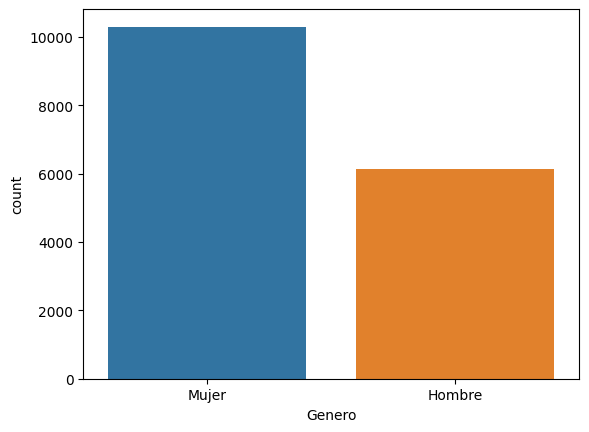

In [ ]:
VendedorCajero = Demo[Demo['Desc Fun'] == 'Vendedor Cajero'] # esta variable aisla todos los vendedores en cajeros dentro de la columna Desc Fun
sns.countplot(data=VendedorCajero, x='Genero')


Nota: La mayoria de las personas con la función de "Vendedor Cajero" son mujeres

###Departamento con la función Vendedor Cajero con más rotaciones.

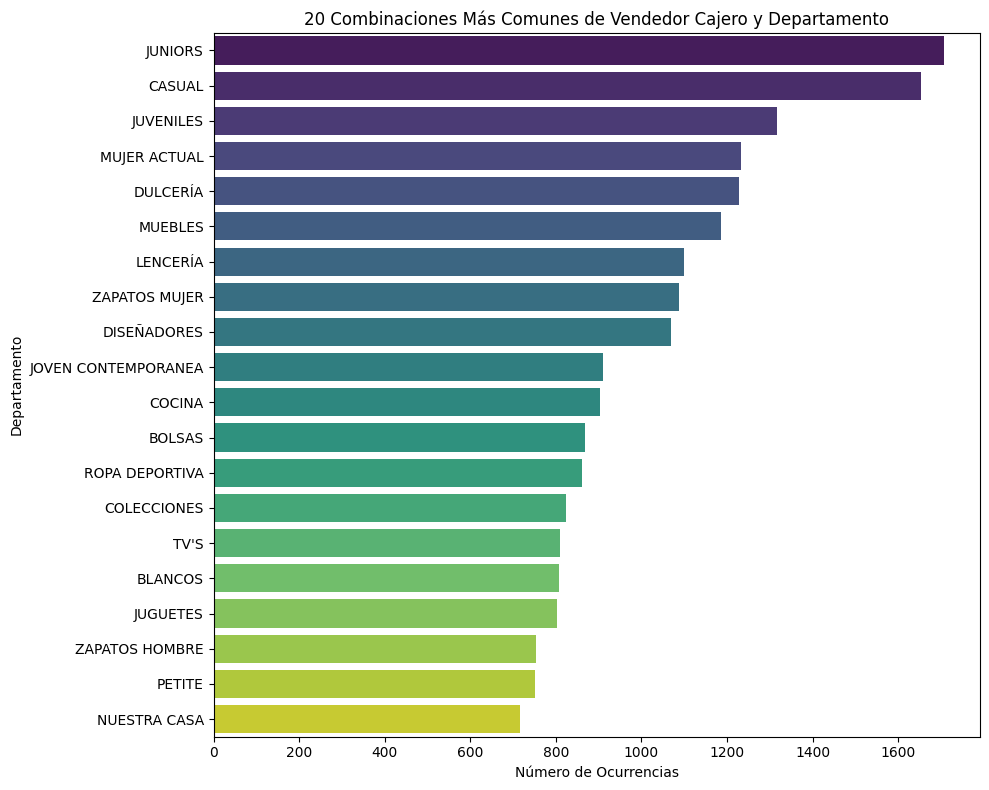

In [ ]:
#TOP 20
vendedor_cajero = Historico[Historico['Desc Función'] == 'Vendedor Cajero']
# Contar el número de ocurrencias para cada combinación única de "vendedor cajero" y "departamento"
conteo_vendedor_departamento = vendedor_cajero.groupby(['Desc Función', 'Departamento']).size().reset_index(name='Count')
# Seleccionar las 20 combinaciones más comunes
top_20_combinaciones = conteo_vendedor_departamento.nlargest(20, 'Count')

# Crear un gráfico de barras horizontal para las 20 combinaciones más comunes
plt.figure(figsize=(10, 8))
sns.barplot(y='Departamento', x='Count', data=top_20_combinaciones, orient='h', palette='viridis')
plt.xlabel('Número de Ocurrencias')
plt.ylabel('Departamento')
plt.title('20 Combinaciones Más Comunes de Vendedor Cajero y Departamento')
plt.tight_layout()
plt.show()